In [ ]:
!pip install -q langgraph langchain-google-genai langchain-groq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from getpass import getpass
from typing import TypedDict, Literal

from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

# ---------------- Config ----------------
PROVIDER = "gemini"   # "gemini" or "groq"
MAX_RETRIES = 2

if PROVIDER == "gemini":
    os.environ["GOOGLE_API_KEY"] = os.environ.get("GOOGLE_API_KEY") or getpass("Gemini API key: ")
    from langchain_google_genai import ChatGoogleGenerativeAI
    llm = ChatGoogleGenerativeAI(model="gemini-3.8-flash", temperature=0)
elif PROVIDER == "groq":
    os.environ["GROQ_API_KEY"] = os.environ.get("GROQ_API_KEY") or getpass("Groq API key: ")
    from langchain_groq import ChatGroq
    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
else:
    raise ValueError("PROVIDER must be 'gemini' or 'groq'")


def text_of(response) -> str:
    """Return response text whether content is a string or a list of parts."""
    c = response.content
    if isinstance(c, list):
        return "".join(p if isinstance(p, str) else p.get("text", "") for p in c)
    return c


# ---------------- State ----------------
class State(TypedDict):
    question: str
    reasoning: str      # chain of thought
    answer: str         # final concise answer
    feedback: str       # verifier feedback (used on retries)
    verdict: str        # "OK" or "REVISE"
    retries: int


# ---------------- Nodes ----------------
def think(state: State) -> dict:
    """CoT step: reason step by step, without giving the final answer yet."""
    system = SystemMessage(
        content=(
            "You are a careful problem solver. Think step by step. "
            "Number each step, show intermediate work, and double-check "
            "calculations. Do NOT state the final answer yet."
        )
    )
    prompt = f"Question: {state['question']}"
    if state.get("feedback"):
        prompt += (
            f"\n\nYour previous reasoning was rejected for this reason:\n"
            f"{state['feedback']}\nFix the mistakes and reason again."
        )
    response = llm.invoke([system, HumanMessage(content=prompt)])
    return {"reasoning": text_of(response)}


def answer(state: State) -> dict:
    """Extract a concise final answer from the reasoning."""
    system = SystemMessage(
        content=(
            "Given a question and step-by-step reasoning, output ONLY the "
            "final answer, as concisely as possible."
        )
    )
    prompt = f"Question: {state['question']}\n\nReasoning:\n{state['reasoning']}"
    response = llm.invoke([system, HumanMessage(content=prompt)])
    return {"answer": text_of(response).strip()}


def verify(state: State) -> dict:
    """Critic step: check the reasoning and answer for errors."""
    system = SystemMessage(
        content=(
            "You are a strict verifier. Check the reasoning and answer for "
            "logical or arithmetic errors. Reply with exactly 'OK' if it is "
            "correct. Otherwise reply with 'REVISE: <what is wrong>'."
        )
    )
    prompt = (
        f"Question: {state['question']}\n\n"
        f"Reasoning:\n{state['reasoning']}\n\n"
        f"Answer: {state['answer']}"
    )
    result = text_of(llm.invoke([system, HumanMessage(content=prompt)])).strip()

    if result.upper().startswith("OK"):
        return {"verdict": "OK", "feedback": ""}
    return {
        "verdict": "REVISE",
        "feedback": result.removeprefix("REVISE:").strip(),
        "retries": state.get("retries", 0) + 1,
    }


# ---------------- Routing ----------------
def route_after_verify(state: State) -> Literal["think", "__end__"]:
    if state["verdict"] == "REVISE" and state["retries"] <= MAX_RETRIES:
        return "think"
    return END


# ---------------- Graph ----------------
builder = StateGraph(State)
builder.add_node("think", think)
builder.add_node("answer", answer)
builder.add_node("verify", verify)

builder.add_edge(START, "think")
builder.add_edge("think", "answer")
builder.add_edge("answer", "verify")
builder.add_conditional_edges("verify", route_after_verify)

graph = builder.compile()


# ---------------- Run ----------------
question = (
    "A train leaves at 9:15 AM traveling 80 km/h. A second train leaves "
    "the same station at 10:00 AM on the same track at 120 km/h. "
    "At what time does the second train catch up?"
)

final = graph.invoke(
    {"question": question, "retries": 0, "feedback": "", "verdict": ""}
)

print("=== REASONING ===")
print(final["reasoning"])
print("\n=== ANSWER ===")
print(final["answer"])
print(f"\n(verdict: {final['verdict']}, retries: {final['retries']})")

=== REASONING ===
1. **Calculate the time difference (head start) between the two departures:**
   - Train 1 departs at 9:15 AM.
   - Train 2 departs at 10:00 AM.
   - Difference in departure time: $10:00 - 9:15 = 45\text{ minutes}$.
   - Convert minutes into hours:
     $$\Delta t = \frac{45}{60}\text{ hours} = 0.75\text{ hours} = \frac{3}{4}\text{ hours}$$

2. **Calculate the distance Train 1 travels before Train 2 departs:**
   - Speed of Train 1 ($v_1$) = $80\text{ km/h}$.
   - Distance covered by Train 1 at 10:00 AM ($d_1$):
     $$d_1 = v_1 \times \Delta t = 80\text{ km/h} \times 0.75\text{ hours} = 60\text{ km}$$

3. **Determine the relative speed of the two trains:**
   - Speed of Train 2 ($v_2$) = $120\text{ km/h}$.
   - Speed of Train 1 ($v_1$) = $80\text{ km/h}$.
   - Relative speed ($v_{\text{rel}}$) with which Train 2 closes the gap:
     $$v_{\text{rel}} = v_2 - v_1 = 120\text{ km/h} - 80\text{ km/h} = 40\text{ km/h}$$

4. **Calculate the time required for Train 2 to catc

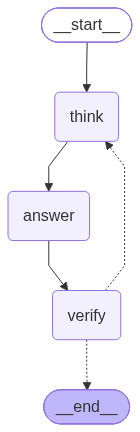

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))